In [ ]:
import numpy as np

# Steps
# Extract arrays
# Add gaussian noise, to inentionally damage the iamges
# Normalize the pixels


# An .npz file is just a container that can hold any NumPy arrays.
# DENTAL_1.NPZ is a NumPy archive file. It's commonly used in machine learning datasets to store arrays efficiently, in this case its already split

data = np.load("DENTAL_1.npz")

print(data.files)

for key in data.files:
    print(key, data[key].shape)

# Extract image arrays
x_train = data["x_train"]
x_test = data["x_test"]

# Convert to float32
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Normalize only if values are 0-255
if x_train.max() > 1:
    x_train = x_train / 255.0
    x_test = x_test / 255.0


# Adding noise to iamges
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

['x_train', 'y_train', 'x_test', 'y_test']
x_train (92, 256, 256, 3)
y_train (92,)
x_test (24, 256, 256, 3)
y_test (24,)
Clean train min/max: 0.0 1.0
Noisy train min/max: 0.0 1.0
x_train shape: (92, 256, 256, 3)
x_train_noisy shape: (92, 256, 256, 3)


In [10]:
# Build Autoencoder with Conv and transposed conv layers 

import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = x_train.shape[1:]


autoencoder = models.Sequential([
    # Encoder
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    # Bottleneck
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),

    # Decoder
    layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same"),

    layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"),

    # Output layer
    layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test_noisy, x_test)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,793 (725.75 KB)

 Trainable params: 185,793 (725.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.0528 - val_loss: 0.0515
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0509 - val_loss: 0.0495
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0477 - val_loss: 0.0442
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0403 - val_loss: 0.0320
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0258 - val_loss: 0.0170
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0147 - val_loss: 0.0148
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0145 - val_loss: 0.0155
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0150 - val_loss: 0.0147
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0136 - val_loss: 0.0118
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0102 - val_loss: 0.0084
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0074 - val_loss: 0.0064
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0061 - val_loss: 0.0057
Epoch 13/20
3/3 ━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


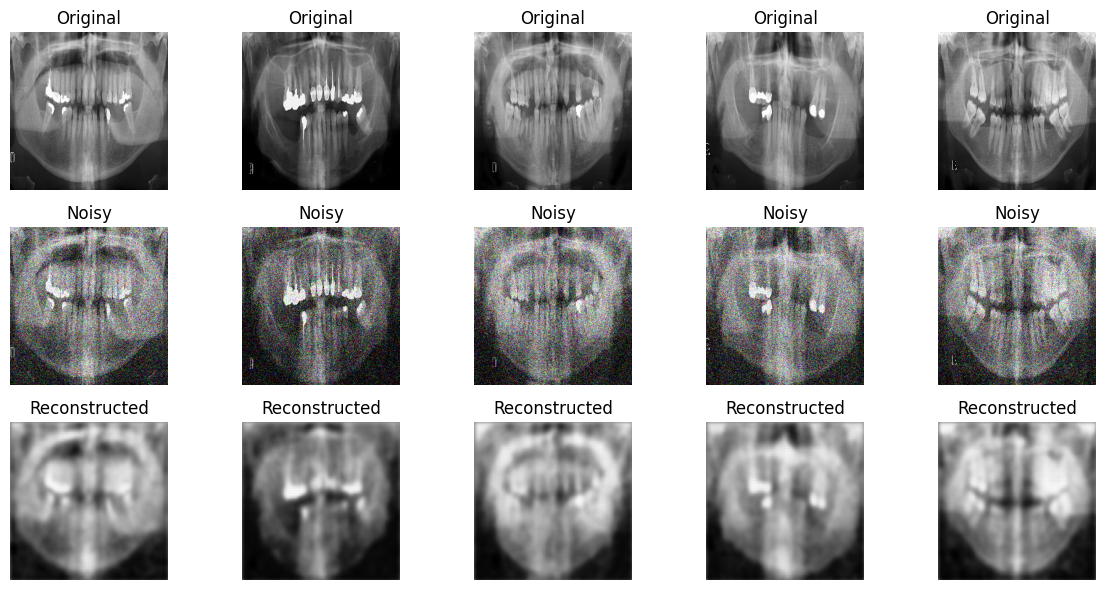

In [11]:
#  Evaluateing performance

reconstructed_images = autoencoder.predict(x_test_noisy)

import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(12, 6))

for i in range(n):
    # Original clean image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(reconstructed_images[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()